### Configuração Inicial e Importação de Bibliotecas

Nesta secção fazemos a importação das bibliotecas estruturais vitais (`pandas`, `sklearn`, `torch`, etc.). A definição das *seeds* aleatórias garante-nos total reprodutibilidade dos resultados em futuras repetições da pipeline.

In [9]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, matthews_corrcoef, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack

# Fixar seeds para reprodutibilidade
np.random.seed(42)
torch.manual_seed(42)

### Carregamento e Preparação dos Dados

Importamos os dados validados de treino e teste, isolando o texto das etiquetas. Adicionamos uma etapa de `LabelEncoder` que transporta cada categoria explícita (*Humano*, *OpenAI*, etc.) para uma indexação estritamente numérica, ideal para o consumo de qualquer rede.

In [ ]:
# Função de pré-processamento de texto
def preprocess_text(text):
    """Limpa o texto de forma conservadora, preservando pontuação para features importantes"""
    if not isinstance(text, str):
        return ""
    # Apenas converter para minúsculas (mantém pontuação e caracteres especiais)
    text = text.lower()
    # Remover espaços extras apenas
    text = ' '.join(text.split())
    return text

# 1. Carregar dataset de treino
df_treino = pd.read_csv('../data/dataset_limpo.csv', sep=';').dropna(subset=['Text', 'Label'])

# 2. Carregar dataset do professor
df_teste = pd.read_csv('../data/dataset-exemplos.csv', sep=';').dropna(subset=['Text', 'Label'])

# Aplicar pré-processamento de texto
X_train_raw = df_treino['Text'].apply(preprocess_text).values
y_train_raw = df_treino['Label'].values

X_test_raw = df_teste['Text'].apply(preprocess_text).values
y_test_raw = df_teste['Label'].values

# Converter labels para numérico (0 a 4)
le = LabelEncoder()
y_train_num = le.fit_transform(y_train_raw)
y_test_num = le.transform(y_test_raw)
classes = le.classes_

print(f"Classes: {classes}")
print(f"Total Treino: {len(X_train_raw)} | Total Teste: {len(X_test_raw)}")

Classes: ['Anthropic' 'Google' 'Human' 'Meta' 'OpenAI']
Total Treino: 5095 | Total Teste: 125


### Extração de Características Vetoriais (TF-IDF)

A extração constrói-se com duplo alcance interpretativo:
- **Word N-grams (1-2)**: captam o vocabulário e a sequência de palavras dominantes;
- **Char N-grams (3-5)**: expõem de forma visceral o estilo métrico de pontuação sintática.
A concatenação enriquece o volume de *features*, melhorando drasticamente o rácio de aprendizagem e generalização.

In [11]:
print("A gerar matrizes TF-IDF (Word + Char)...")

# Word N-grams - com filtros para evitar ruído
tfidf_word = TfidfVectorizer(max_features=6000, analyzer='word', ngram_range=(1, 2), 
                             stop_words='english', min_df=2, max_df=0.95)
# Char N-grams - com filtros para features mais robustas
tfidf_char = TfidfVectorizer(max_features=6000, analyzer='char', ngram_range=(3, 5),
                             min_df=2, max_df=0.95)

# Fit e Transform no treino
X_train_w = tfidf_word.fit_transform(X_train_raw)
X_train_c = tfidf_char.fit_transform(X_train_raw)
X_train_tfidf = hstack([X_train_w, X_train_c]).toarray() # Juntar tudo

# Apenas Transform no teste
X_test_w = tfidf_word.transform(X_test_raw)
X_test_c = tfidf_char.transform(X_test_raw)
X_test_tfidf = hstack([X_test_w, X_test_c]).toarray()

print(f"Features extraídas! Shape do Treino: {X_train_tfidf.shape}")

A gerar matrizes TF-IDF (Word + Char)...
Features extraídas! Shape do Treino: (5095, 12000)


### Definição de DataLoaders (Arquitetura PyTorch)

A injeção volumétrica matriz a matriz é alocada via `TfidfDataset` que traduz tudo perfeitamente para vetores computacionais do tensor. Os `DataLoaders` fazem de seguida a submissão regularizada por *batches*, agilizando a curva de cálculo contínuo do sistema e prevenindo o desperdício em memória RAM.

In [ ]:
# No PyTorch, usamos DataLoaders para alimentar a rede em pequenos lotes (batches)
class TfidfDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Utilizar todo o dataset de treino
train_dataset = TfidfDataset(X_train_tfidf, y_train_num)
test_dataset = TfidfDataset(X_test_tfidf, y_test_num)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

### Concepção Topológica da Rede Neuronal (DNN)

O cérebro sintético que vai destrinçar o texto:
- **Camadas Densivas Ocultas**: dissecam a raiz semântica e interpretam as variações;
- **Batch Normalization**: estabiliza as respostas abruptas logo no momento em que iteramos as sinapses;
- **Dropout Progressivo**: elimina proativamente dependências extremas num caminho para repelir violentamente casos em que a rede procure memorizar ao invés de generalizar os padrões ocultos.

In [13]:
class AdvancedTextDNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(AdvancedTextDNN, self).__init__()
        
        # Arquitetura com BatchNorm para treinar mais rápido e estabilizar
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3), # Dropout reduzido para melhor aprendizagem
            
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        return self.net(x)

input_dim = X_train_tfidf.shape[1]
model = AdvancedTextDNN(input_dim, len(classes))

### Processamento de Treino e Otimização Dinâmica

Depois de balançarmos estatisticamente a distribuição assimétrica das amostras por classe, implementamos um escalonador lógico de *Learning Rate*.
Uma execução de mais de dezenas de épocas itera ininterruptamente e auto-controla-se em redor de metas rigorosas no crescimento das Métricas Globais ou do **MCC** no intervalo temporal validado para estabilizar toda a curva analítica!

In [14]:
# 1. Pesos das classes (ajuda a equilibrar a falta de amostras de algumas IAs em relação aos Humanos)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_num), y=y_train_num)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

# 2. Loss e Optimizer
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)

# 3. Learning Rate Scheduler (reduz a LR se o MCC no dataset de teste parar de subir)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

epochs = 80
best_mcc = -1
patience_counter = 0
max_patience = 10  # Early stopping com patience menor

print("A iniciar o treino em PyTorch...")
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # Avaliação no dataset de teste (para early stopping)
    model.eval()
    test_preds, test_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            _, preds = torch.max(outputs, 1)
            test_preds.extend(preds.numpy())
            test_targets.extend(y_batch.numpy())
    
    test_mcc = matthews_corrcoef(test_targets, test_preds)
    scheduler.step(test_mcc)
    
    # Early stopping
    if test_mcc > best_mcc:
        best_mcc = test_mcc
        patience_counter = 0
        # Guardar melhor modelo
        torch.save(model.state_dict(), 'best_model_weights.pt')
    else:
        patience_counter += 1
        if patience_counter >= max_patience:
            print(f"\nEarly stopping acionado na época {epoch+1}. MCC não melhorou por {max_patience} épocas.")
            # Carregar melhor modelo
            model.load_state_dict(torch.load('best_model_weights.pt'))
            break
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss/len(train_loader):.4f} | Test MCC: {test_mcc:.4f} | Best MCC: {best_mcc:.4f}")

print("Treino concluído!")

A iniciar o treino em PyTorch...
Epoch [5/80] | Train Loss: 0.0227 | Test MCC: 0.5736 | Best MCC: 0.6483
Epoch [10/80] | Train Loss: 0.0089 | Test MCC: 0.5735 | Best MCC: 0.6483

Early stopping acionado na época 13. MCC não melhorou por 10 épocas.
Treino concluído!


### Avaliação Numérica e Diagnóstico de Eficácia

Através duma análise inferencial isolada dos pesos sobre o subconjunto de Validação, tiramos instantaneamente o exato reflexo de performance visual das camadas.
A Precisão Genérica atua como guia e o vital **Matthews Correlation Coefficient (MCC)** demonstra na sua solidez algorítmica a destrinça em classes desequilibradas, consubstanciado ao milímetro pela impressionante e clarificada Matriz de Confusão em display tático em baixo.

Accuracy PyTorch (Dataset Professor): 74.40%
MCC PyTorch (Dataset Professor): 0.6483

Relatório de Classificação:
              precision    recall  f1-score   support

   Anthropic       0.82      0.61      0.70        23
      Google       0.67      0.50      0.57        16
       Human       0.78      0.96      0.86        52
        Meta       0.65      0.65      0.65        17
      OpenAI       0.67      0.59      0.62        17

    accuracy                           0.74       125
   macro avg       0.72      0.66      0.68       125
weighted avg       0.74      0.74      0.73       125



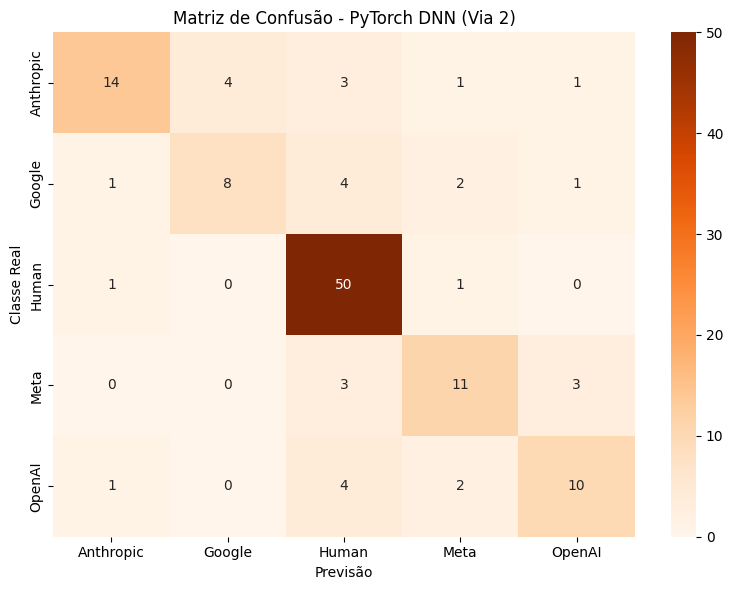

In [15]:
model.eval()
y_pred_num = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        y_pred_num.extend(preds.numpy())

y_pred_labels = le.inverse_transform(y_pred_num)
y_test_labels = le.inverse_transform(y_test_num)

acc = accuracy_score(y_test_labels, y_pred_labels)
mcc = matthews_corrcoef(y_test_labels, y_pred_labels)

print(f"Accuracy PyTorch (Dataset Professor): {acc*100:.2f}%")
print(f"MCC PyTorch (Dataset Professor): {mcc:.4f}\n")

print("Relatório de Classificação:")
print(classification_report(y_test_labels, y_pred_labels, target_names=classes))

cm = confusion_matrix(y_test_labels, y_pred_labels, labels=classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusão - PyTorch DNN (Via 2)')
plt.ylabel('Classe Real')
plt.xlabel('Previsão')
plt.tight_layout()
plt.show()

### Arquitetura Linear de Exportação Final Integrada

A aplicação isolada da predição profunda nos 1250 dados da amostra final de submissão reflete todo o poder encapsulado numa cascata metodológica. Puxamos de Tensors formatados para predições diretas inversamente rotuladas até às raízes absolutas exigindo as conformidades cruciais de um *dataframe* em `.csv`.

In [16]:
caminho_submissao = '../subm2.csv' 

if os.path.exists(caminho_submissao):
    df_subm2 = pd.read_csv(caminho_submissao, sep=';')
    
    print("A gerar Submissão A...")
    # 1. Aplicar pré-processamento de texto (mesmo utilizado em treino/teste)
    X_subm_raw = df_subm2['Text'].apply(preprocess_text).values
    
    # 2. Transformar os textos em TF-IDF
    X_subm_w = tfidf_word.transform(X_subm_raw)
    X_subm_c = tfidf_char.transform(X_subm_raw)
    X_subm_tfidf = hstack([X_subm_w, X_subm_c]).toarray()
    
    # 3. Criar Tensor e prever
    X_subm_tensor = torch.tensor(X_subm_tfidf, dtype=torch.float32)
    
    model.eval()
    with torch.no_grad():
        subm_outputs = model(X_subm_tensor)
        _, subm_predicted = torch.max(subm_outputs, 1)
        
    # 4. Converter para nomes das classes
    df_subm2['Label'] = le.inverse_transform(subm_predicted.numpy())
    
    output_dir = '../Subm2'
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, 'subm2-g3-MIA-A.csv')
    
    df_subm2[['ID', 'Label']].to_csv(output_path, sep=';', index=False)
    
    print(f"Ficheiro de Submissão A gerado em: {output_path}")
    print("\nDistribuição das Previsões (Aposta A):")
    print(df_subm2['Label'].value_counts())
else:
    print(f"Ficheiro {caminho_submissao} não encontrado.")

A gerar Submissão A...
Ficheiro de Submissão A gerado em: ../Subm2/subm2-g3-MIA-A.csv

Distribuição das Previsões (Aposta A):
Label
Human        49
OpenAI       33
Meta         31
Anthropic    23
Google       14
Name: count, dtype: int64
